# Evaluation Report for the paper "_dlinear_ : Enhancing SMT Solvers with Floating-Point Exact LP Solvers"

**Date:** March 2026
**Benchmarks:** SMT-LIB QF_LRA (1753 instances)
**Computing Platform:** AMD EPYC 9745, 4GB Memory, 6-hour timeout

---

## Executive Summary

This report presents a comprehensive evaluation of integrating floating-point exact LP solvers into the [cvc5](https://github.com/cvc5/cvc5) SMT solver for linear arithmetic reasoning. 
We compare the performance of the baseline cvc5 implementation with augmented versions using [GLPK](https://www.gnu.org/software/glpk/), [SoPlex](https://github.com/scipopt/soplex) and [qsoptex](https://github.com/TendTo/qsopt-ex) as external LP solvers, across various pivot limits and modes of operation.
Moreover, we also give a comparison with the state-of-the-art SMT solver [Z3](https://github.com/Z3Prover/z3) and [yices](https://github.com/SRI-CSL/yices) to contextualize the performance of our approach.

The evaluation demonstrates that our integration provides significant performance improvements, particularly for instances requiring intensive linear arithmetic reasoning.

---

In [1]:
from IPython.display import Markdown as md
import pandas as pd
import numpy as np
import random
from functools import reduce
from utils import (
    convert_to_numeric,
    split_dict_columns,
    get_tot_results_compare,
    compare_unique_solved_instances,
    build_markdown_comparison_matrix,
    copy_instances,
    plot_performance_profiles,
    plot_time_histogram,
    query_time,
    sanitize,
    difficulty_analysis,
    print_stats,
    SolverResult,
    SOPLEX,
    GLPK,
    QSOPTEX,
    external_solver_impact,
)
from itertools import product
import matplotlib.pyplot as plt
import os

In [2]:
DROP_UNSOLVED = False

In [3]:
all_instances = pd.read_csv("instances/all_instances.csv").set_index("file")
instances_100 = pd.read_csv("instances/100_instances.csv").set_index("file")
instances_200 = pd.read_csv("instances/200_instances.csv").set_index("file")
instances_300 = pd.read_csv("instances/300_instances.csv").set_index("file")
mplib = pd.read_csv("instances/mplib.csv").set_index("file")
lanteresse = pd.read_csv("instances/lanteresse.csv").set_index("file")
dtp_scheduling = pd.read_csv("instances/dtp-scheduling.csv").set_index("file")

instances_dict = {
    100: instances_100,
    200: instances_200,
    300: instances_300,
}

def in_n(df: pd.DataFrame, n: int) -> pd.DataFrame:
    return df[df.index.isin(instances_dict[n].index)]

def in_instances(df: pd.DataFrame, *instances: pd.DataFrame) -> pd.DataFrame:
    if len(instances) == 0:
        return df
    if len(instances) == 1:
        return df[df.index.isin(instances[0].index)]
    return df[df.index.isin(pd.merge(*instances, how="inner", left_index=True, right_index=True).index)]

In [4]:
SOLVERS = ("soplex", "qsoptex")
ITERATIONS = (100, 200, 300)
MODES = ("", "_strict",) #"_delta1e-08")
results: dict[str, SolverResult] = {}

In [5]:
for solver, iteration, m in product(SOLVERS, ITERATIONS, MODES):
    key = f"{solver}_i{iteration}{m}"
    file = f"results/{key}.csv"
    solver_id = solver[0].upper()
    if os.path.exists(file):
        print(f"Loading results from {file}...")
        df = pd.read_csv(file).set_index("file")
        if DROP_UNSOLVED:
            df = df[df[f"result{solver_id}"].isin(["sat", "unsat"])]
        if m == "_strict":
            mode_str = "t"
        elif m == "_delta1e-08":
            mode_str = r"\delta"
        else:
            mode_str = r"\varepsilon"
        results[key] = SolverResult(solver_name=fr"$ \textbf{{d}}_{{{solver[:2].lower()},{iteration}}}^{mode_str} $", dataframe=df, solver_id=solver_id, iterations=iteration)

for key in results:
    results[key] = results[key].replace_df(sanitize(results[key].dataframe))

Loading results from results/soplex_i100.csv...
Loading results from results/soplex_i100_strict.csv...
Loading results from results/soplex_i200.csv...
Loading results from results/soplex_i200_strict.csv...
Loading results from results/soplex_i300.csv...
Loading results from results/qsoptex_i100.csv...
Loading results from results/qsoptex_i100_strict.csv...
Loading results from results/qsoptex_i200.csv...
Loading results from results/qsoptex_i200_strict.csv...
Loading results from results/qsoptex_i300.csv...


# Benchmarks

## Section 1: Overall Benchmark Performance

### 1.1 Problems Solved

This section summarizes the total number of instances solved by each approach across the entire QF_LRA benchmark set.

We are using the [SMT-LIB](https://smt-lib.org/benchmarks.shtml) benchmarks for our evaluation.

To be precise, we are using the [QF_LRA](https://smt-lib.org/logics-all.shtml#QF_LRA) theory benchmarks from the [SMT-LIB release 2025 of non-incremental benchmarks](https://zenodo.org/records/16740866).
The set is composed of 1753 instances, but only a subset of them would be used for our evaluation, as we are only interested in instances that call the external LP solver at least once.
We ran with a timeout of 6 hours and a memory limit of 4GB.
We used the Comet HPC cluster from Newcastle University.
Each node uses an AMD EPYC 9745 @ 2.4 GHz 128-core processor (256 threads), although we only used one core per instance.

### Hardware details

| OS            | CPU           | Architecture | Frequency | Turbo frequency | Cores | Memory | L1      | L2        | L3     | Time limit |
| ------------- | ------------- | ------------ | --------- | --------------- | ----- | ------ | ------- | --------- | ------ | ---------- |
| RHEL 11.4.1-4 | AMD EPYC 9745 | x86_64       | 2.4 GHz   | 3.7 GHz         | 1     | 4GB    | 6144 KB | 131072 KB | 256 MB | 6 hours    |

In [6]:
def get_tot_results(df: pd.DataFrame) -> int:
    assert len(df["options::pivots"].unique()) > 0
    tot = 1753
    table_entries_by_pivot = []
    for pivots in df["options::pivots"].unique():
        for solver in df["theory::arith::z::approx::externalSimplexType"].unique():
            for strict in df["options::strict"].unique():
                for delta in df["options::delta"].unique():
                    if pd.isna(solver):
                        continue
                    sub_df = df[(df["options::pivots"] == pivots) & (df["theory::arith::z::approx::externalSimplexType"] == solver) & (df["options::strict"] == strict) & (df["options::delta"] == delta) & (df["result"].isin(["sat", "unsat"]))]
                    solved = len(sub_df)
                    if solved == 0:
                        continue
                    tot = len(in_n(all_instances, pivots))
                    entry =  f"| **{solver}** | {'✔' if strict else ''} | {delta if delta >= 0 else ' '} | {pivots} | {tot} | {solved} ({(solved / tot * 100):.1f}%) | {tot - solved} ({(tot - solved) / tot * 100:.1f}%) |"
                    table_entries_by_pivot.append(entry)
    table_rows = "\n".join(table_entries_by_pivot)
    return f"""
### Benchmarks details
    
| Solver | Strict   | Delta | Pivot threshold | Number of instances | Solved instances | Unsolved instances |
| ------ | -------- | ----- | --------------- | ------------------- | ---------------- | ------------------ |
{table_rows}
"""
md(get_tot_results(pd.concat([result.dataframe for result in results.values()])))


### Benchmarks details

| Solver | Strict   | Delta | Pivot threshold | Number of instances | Solved instances | Unsolved instances |
| ------ | -------- | ----- | --------------- | ------------------- | ---------------- | ------------------ |
| **SOPLEX** |  |   | 100 | 319 | 287 (90.0%) | 32 (10.0%) |
| **SOPLEX** | ✔ |   | 100 | 319 | 254 (79.6%) | 65 (20.4%) |
| **QSOPTEX** |  |   | 100 | 319 | 281 (88.1%) | 38 (11.9%) |
| **QSOPTEX** | ✔ |   | 100 | 319 | 287 (90.0%) | 32 (10.0%) |
| **SOPLEX** |  |   | 200 | 177 | 153 (86.4%) | 24 (13.6%) |
| **SOPLEX** | ✔ |   | 200 | 177 | 151 (85.3%) | 26 (14.7%) |
| **QSOPTEX** |  |   | 200 | 177 | 150 (84.7%) | 27 (15.3%) |
| **QSOPTEX** | ✔ |   | 200 | 177 | 155 (87.6%) | 22 (12.4%) |
| **SOPLEX** |  |   | 300 | 125 | 107 (85.6%) | 18 (14.4%) |
| **QSOPTEX** |  |   | 300 | 125 | 99 (79.2%) | 26 (20.8%) |


In [7]:
pairwise_only = compare_unique_solved_instances(*list(results.values()))
solver_order = [solver.solver_name for solver in results.values()]

md(build_markdown_comparison_matrix(pairwise_only, solver_order))

### Pairwise matrix (instances solved by row solver but not by column solver)
| Solver A \ Solver B | $ \textbf{d}_{so,100}^\varepsilon $ | $ \textbf{d}_{so,100}^t $ | $ \textbf{d}_{so,200}^\varepsilon $ | $ \textbf{d}_{so,200}^t $ | $ \textbf{d}_{so,300}^\varepsilon $ | $ \textbf{d}_{qs,100}^\varepsilon $ | $ \textbf{d}_{qs,100}^t $ | $ \textbf{d}_{qs,200}^\varepsilon $ | $ \textbf{d}_{qs,200}^t $ | $ \textbf{d}_{qs,300}^\varepsilon $ |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| $ \textbf{d}_{so,100}^\varepsilon $ |  | 38 | 144 | 149 | 191 | 11 | 10 | 144 | 143 | 195 |
| $ \textbf{d}_{so,100}^t $ | 5 |  | 140 | 140 | 175 | 9 | 6 | 140 | 139 | 177 |
| $ \textbf{d}_{so,200}^\varepsilon $ | 10 | 39 |  | 7 | 51 | 14 | 10 | 6 | 2 | 55 |
| $ \textbf{d}_{so,200}^t $ | 13 | 37 | 5 |  | 53 | 16 | 10 | 8 | 6 | 59 |
| $ \textbf{d}_{so,300}^\varepsilon $ | 11 | 28 | 5 | 9 |  | 14 | 9 | 8 | 5 | 9 |
| $ \textbf{d}_{qs,100}^\varepsilon $ | 5 | 36 | 142 | 146 | 188 |  | 6 | 142 | 142 | 191 |
| $ \textbf{d}_{qs,100}^t $ | 10 | 39 | 144 | 146 | 189 | 12 |  | 144 | 143 | 192 |
| $ \textbf{d}_{qs,200}^\varepsilon $ | 7 | 36 | 3 | 7 | 51 | 11 | 7 |  | 1 | 54 |
| $ \textbf{d}_{qs,200}^t $ | 11 | 40 | 4 | 10 | 53 | 16 | 11 | 6 |  | 56 |
| $ \textbf{d}_{qs,300}^\varepsilon $ | 7 | 22 | 1 | 7 | 1 | 9 | 4 | 3 | 0 |  |

## Section 2: Solver Comparison

### 2.1 dlinear vs. GLPK vs. Baseline cvc5 vs. Z3 vs. yices

This section provides a comprehensive comparison of the three main approaches evaluated in this study.

In [8]:
others = ("glpk_i100", "glpk_i200", "glpk_i300", "yices", "z3", "cvc5", )
others_results: dict[str, SolverResult] = {}
for others in others:
    if os.path.exists(f"results/{others}.csv"):
        print(f"Loading results from results/{others}.csv...")
        df = pd.read_csv(f"results/{others}.csv").set_index("file")
        if DROP_UNSOLVED:
            df = df[df[f"result{others[0].upper()}"].isin(["sat", "unsat"])]
        iterations = f"_{{{others.split('_')[-1][1:]}}}" if "glpk" in others else ""
        others_results[others] = SolverResult(solver_name=fr"$ \textbf{{{others[0].lower()}}}{iterations} $", dataframe=df, solver_id=others[0].upper(), iterations=int(iterations[2:-1]) if iterations else -1)

Loading results from results/glpk_i100.csv...
Loading results from results/glpk_i200.csv...
Loading results from results/glpk_i300.csv...
Loading results from results/yices.csv...
Loading results from results/z3.csv...
Loading results from results/cvc5.csv...


In [9]:
def get_tot_results_compare(result: SolverResult, iterations_filter: list[tuple[int, pd.DataFrame]]) -> int:
    header = ""
    middle = ""
    row = ""
    for iterations, instances in iterations_filter:
        results = result.dataframe[result.dataframe.index.isin(instances.index)]
        results = results[results[result.result_key].isin(["sat", "unsat"])]
        not_solved = len(instances) - len(results)
        header += f"| $n={iterations}$ solved | $n={iterations}$ unsolved "
        middle += f"| --- | --- "
        row += f"| {len(results)}/ {len(instances)} ({(len(results) / len(instances) * 100):.1f}%) | {not_solved}/ {len(instances)} ({(not_solved / len(instances) * 100):.1f}%) "
    return f"""
#### {result.solver_name} results for all pivots

| Solver               {header} |
| -------------------- {middle} |
| {result.solver_name} {row} |
"""

In [10]:
md(get_tot_results_compare(others_results["yices"], iterations_filter=instances_dict.items()))


#### $ \textbf{y} $ results for all pivots

| Solver               | $n=100$ solved | $n=100$ unsolved | $n=200$ solved | $n=200$ unsolved | $n=300$ solved | $n=300$ unsolved  |
| -------------------- | --- | --- | --- | --- | --- | ---  |
| $ \textbf{y} $ | 295/ 319 (92.5%) | 24/ 319 (7.5%) | 156/ 177 (88.1%) | 21/ 177 (11.9%) | 109/ 125 (87.2%) | 16/ 125 (12.8%)  |


In [11]:
md(get_tot_results_compare(others_results["z3"], iterations_filter=instances_dict.items()))


#### $ \textbf{z} $ results for all pivots

| Solver               | $n=100$ solved | $n=100$ unsolved | $n=200$ solved | $n=200$ unsolved | $n=300$ solved | $n=300$ unsolved  |
| -------------------- | --- | --- | --- | --- | --- | ---  |
| $ \textbf{z} $ | 276/ 319 (86.5%) | 43/ 319 (13.5%) | 140/ 177 (79.1%) | 37/ 177 (20.9%) | 95/ 125 (76.0%) | 30/ 125 (24.0%)  |


In [12]:
md(get_tot_results_compare(others_results["cvc5"], iterations_filter=instances_dict.items()))


#### $ \textbf{c} $ results for all pivots

| Solver               | $n=100$ solved | $n=100$ unsolved | $n=200$ solved | $n=200$ unsolved | $n=300$ solved | $n=300$ unsolved  |
| -------------------- | --- | --- | --- | --- | --- | ---  |
| $ \textbf{c} $ | 289/ 319 (90.6%) | 30/ 319 (9.4%) | 149/ 177 (84.2%) | 28/ 177 (15.8%) | 100/ 125 (80.0%) | 25/ 125 (20.0%)  |


In [13]:
md(get_tot_results_compare(others_results["glpk_i100"], iterations_filter=[instance for instance in instances_dict.items() if instance[0] == 100]))


#### $ \textbf{g}_{100} $ results for all pivots

| Solver               | $n=100$ solved | $n=100$ unsolved  |
| -------------------- | --- | ---  |
| $ \textbf{g}_{100} $ | 199/ 319 (62.4%) | 120/ 319 (37.6%)  |


In [14]:
md(get_tot_results_compare(others_results["glpk_i200"], iterations_filter=[instance for instance in instances_dict.items() if instance[0] == 200]))


#### $ \textbf{g}_{200} $ results for all pivots

| Solver               | $n=200$ solved | $n=200$ unsolved  |
| -------------------- | --- | ---  |
| $ \textbf{g}_{200} $ | 112/ 177 (63.3%) | 65/ 177 (36.7%)  |


In [15]:
md(get_tot_results_compare(others_results["glpk_i300"], iterations_filter=[instance for instance in instances_dict.items() if instance[0] == 300]))


#### $ \textbf{g}_{300} $ results for all pivots

| Solver               | $n=300$ solved | $n=300$ unsolved  |
| -------------------- | --- | ---  |
| $ \textbf{g}_{300} $ | 38/ 125 (30.4%) | 87/ 125 (69.6%)  |


### 2.2 Comparison between external LP solvers: GLPK, SoPlex and qsoptex

We compare the performance of the three external LP solvers (GLPK, SoPlex and qsoptex) when integrated into cvc5, across different pivot limits and modes of operation.

In [16]:
md(print_stats(
    soplex_configs=(results | {key: others_results[key] for key in others_results if others_results[key].solver_id == "G"}).values()
))

### Summary statistics by SoPlex pivot limit
| Config       | Registered results | Solved | Unknown | Tot Time | Med Time | Med LP Time | Med LP Setup Time | Feasible failures | Infeasible failures | Tot Failures | Failure rate | Adjustment calls | Med Adjustment calls | $>1$ Adj. Pivot |
| ------------ | -------------- | ------ | ------- | ---------- | --------- | ---- | ---- | ------------- | ------------------- | ------------ | ------------ | ---------------- | ---------------------- | ----------------- |
| $ \textbf{d}_{so,100}^\varepsilon $ | 305 | 287 | 18 | 789132 | 251.31           | 1083.00         | 339.00          | 1 | 49 | 50 | 16.39% | 4127997 | 944.00          | 56 |
| $ \textbf{d}_{so,100}^t $ | 255 | 254 | 1 | 209243 | 152.08           | 241.00          | 196.00          | 9 | 1 | 10 | 3.92% | 3864 | 7.00            | 26 |
| $ \textbf{d}_{so,200}^\varepsilon $ | 168 | 153 | 15 | 589429 | 549.74           | 2314.00         | 661.00          | 0 | 31 | 31 | 18.45% | 2685263 | 2455.00         | 35 |
| $ \textbf{d}_{so,200}^t $ | 160 | 151 | 9 | 424699 | 262.30           | 410.00          | 450.00          | 5 | 1 | 6 | 3.75% | 325836 | 223.00          | 9 |
| $ \textbf{d}_{so,300}^\varepsilon $ | 117 | 107 | 10 | 410879 | 247.12           | 1620.00         | 407.00          | 0 | 30 | 30 | 25.64% | 247412 | 481.00          | 34 |
| $ \textbf{d}_{qs,100}^\varepsilon $ | 295 | 281 | 14 | 646182 | 211.94           | 3516.00         | 745.00          | 1 | 0 | 1 | 0.34% | 4187 | 76.00           | 29 |
| $ \textbf{d}_{qs,100}^t $ | 303 | 287 | 16 | 717837 | 219.37           | 625.00          | 1400.00         | 0 | 13 | 13 | 4.29% | 760107 | 37.00           | 25 |
| $ \textbf{d}_{qs,200}^\varepsilon $ | 159 | 150 | 9 | 421687 | 282.19           | 4427.00         | 965.00          | 0 | 0 | 0 | 0.00% | 291 | 1.00            | 9 |
| $ \textbf{d}_{qs,200}^t $ | 167 | 155 | 12 | 494954 | 351.37           | 1073.00         | 1234.00         | 0 | 5 | 5 | 2.99% | 4485 | 28.00           | 11 |
| $ \textbf{d}_{qs,300}^\varepsilon $ | 110 | 99 | 11 | 359802 | 221.77           | 7168.00         | 1278.00         | 0 | 0 | 0 | 0.00% | 345 | 1.00            | 7 |
| $ \textbf{g}_{100} $ | 312 | 199 | 113 | 2631490 | 948.99           | 1352.00         | 2648.00         | 221 | 3 | 224 | 71.79% | 493542310 | 209103.00       | 268 |
| $ \textbf{g}_{200} $ | 171 | 112 | 59 | 1421538 | 1463.37          | 335.00          | 342.00          | 119 | 3 | 122 | 71.35% | 289651830 | 16919.00        | 149 |
| $ \textbf{g}_{300} $ | 38 | 38 | 0 | 25571 | 27.25            | 42.00           | 28.00           | 19 | 0 | 19 | 50.00% | 1412951 | 147.00          | 30 |
    

### 2.3: External solver impact

Calls to the external simplex solver can be expensive for the overall performance of the SMT solver, especially when many of them are required or when the techniques to obtain the exact solution become costly, which is the case for numerically challenging instances.
Here, we analyze the impact of precision boosting (i.e., the number $p_n$ of calls that ended with $n$ bits of precision) and iterative refinements (i.e., the number $r_i$ of calls that used $i$ refinements to solve the problem) on the overall performance of the solver.

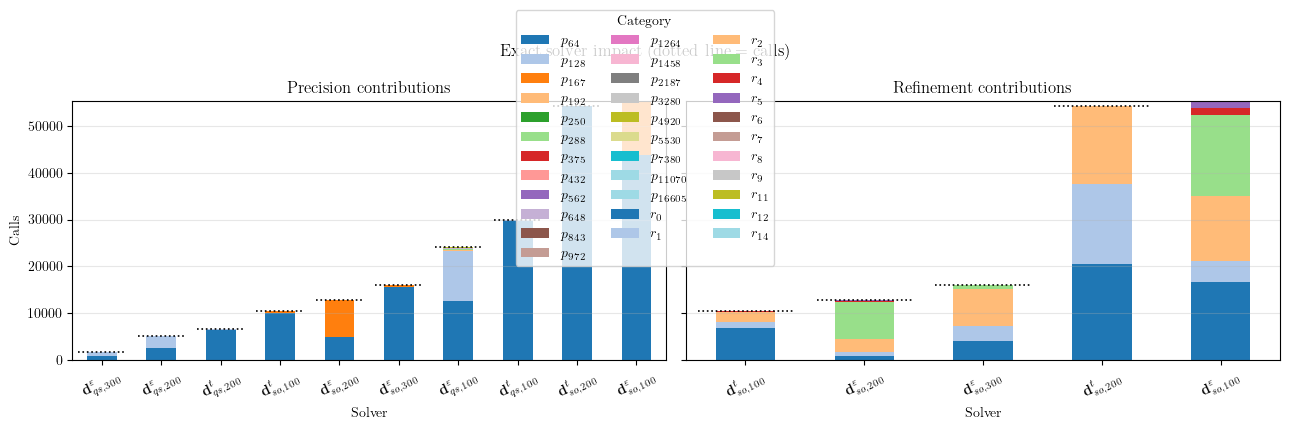

## External solver impact

Analysis on the impact of the external simplex solver on the overall performance of the SMT solver, based on the number of calls to the external simplex and the techniques used to obtain the exact solution (precision boosting and iterative refinements).
    
| Solver | Calls | $p_{64}$ | $p_{128}$ | $p_{167}$ | $p_{192}$ | $p_{250}$ | $p_{288}$ | $p_{375}$ | $p_{432}$ | $p_{562}$ | $p_{648}$ | $p_{843}$ | $p_{972}$ | $p_{1264}$ | $p_{1458}$ | $p_{2187}$ | $p_{3280}$ | $p_{4920}$ | $p_{5530}$ | $p_{7380}$ | $p_{11070}$ | $p_{16605}$ | $r_{0}$ | $r_{1}$ | $r_{2}$ | $r_{3}$ | $r_{4}$ | $r_{5}$ | $r_{6}$ | $r_{7}$ | $r_{8}$ | $r_{9}$ | $r_{11}$ | $r_{12}$ | $r_{14}$ |
| ------ | ----- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| $ \textbf{d}_{so,100}^\varepsilon $ | 55234 | 43747 | | 11392 | | 42 | | 14 | | 5 | | 6 | | 28 | | | | | | | | | 16569 | 4521 | 13962 | 17370 | 1517 | 1104 | 71 | 66 | 51 | 2 | 1 | | |
| $ \textbf{d}_{so,100}^t $ | 10467 | 10105 | | 357 | | 5 | | | | | | | | | | | | | | | | | 6800 | 1407 | 1980 | 113 | 89 | 61 | 2 | 9 | 4 | 1 | | 1 | |
| $ \textbf{d}_{so,200}^\varepsilon $ | 12835 | 4996 | | 7735 | | 32 | | 23 | | 14 | | 8 | | 27 | | | | | | | | | 893 | 753 | 2904 | 7773 | 181 | 290 | 26 | 6 | 5 | | | | 4 |
| $ \textbf{d}_{so,200}^t $ | 54240 | 54229 | | 11 | | | | | | | | | | | | | | | | | | | 20440 | 17235 | 16557 | 4 | 3 | 1 | | | | | | | |
| $ \textbf{d}_{so,300}^\varepsilon $ | 16054 | 15495 | | 484 | | 37 | | 8 | | 8 | | 5 | | 17 | | | | | | | | | 4080 | 3076 | 8075 | 755 | 43 | 20 | 3 | 2 | 0 | | | | |
| $ \textbf{d}_{qs,100}^\varepsilon $ | 24104 | 12650 | 10736 | | 151 | | 88 | | 35 | | 361 | | 6 | | 2 | 1 | 1 | 2 | 1 | 2 | 1 | 67 | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,100}^t $ | 29877 | 29635 | 238 | | 2 | | 2 | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,200}^\varepsilon $ | 5191 | 2565 | 2508 | | 33 | | 23 | | 10 | | 47 | | 2 | | | | | | | | | 3 | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,200}^t $ | 6605 | 6377 | 228 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,300}^\varepsilon $ | 1716 | 912 | 746 | | 13 | | 8 | | 5 | | 28 | | 1 | | | | | | | | | 3 | | | | | | | | | | | | | |
| $ \textbf{g}_{100} $ | 404675 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{g}_{200} $ | 106046 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{g}_{300} $ | 4678 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |


In [17]:
md(external_solver_impact(
    solvers_analysis=(results | {key: others_results[key] for key in others_results if others_results[key].solver_id == "G"}).values()
))

## Section 3: Time Distribution and Instance Difficulty Analysis

### 3.1 Performance Profile Analysis

The following performance profiles help visualize how well each solver performs across the entire benchmark set.

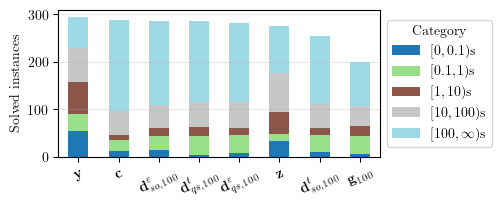

## Difficulty analysis on 100

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 55 (18.6%) | 35 (11.9%) | 68 (23.1%) | 72 (24.4%) | 65 (22.0%) | 295 / 319 (92.5%)
| $ \textbf{z} $ |  | 0 | 34 (12.3%) | 14 (5.1%) | 46 (16.7%) | 83 (30.1%) | 99 (35.9%) | 276 / 319 (86.5%)
| $ \textbf{c} $ |  | 0 | 12 (4.2%) | 24 (8.3%) | 10 (3.5%) | 50 (17.3%) | 193 (66.8%) | 289 / 319 (90.6%)
| $ \textbf{g}_{100} $ |  | 100 | 6 (3.0%) | 38 (19.1%) | 22 (11.1%) | 41 (20.6%) | 92 (46.2%) | 199 / 319 (62.4%)
| $ \textbf{d}_{so,100}^\varepsilon $ |  | 100 | 14 (4.9%) | 30 (10.5%) | 16 (5.6%) | 50 (17.4%) | 177 (61.7%) | 287 / 319 (90.0%)
| $ \textbf{d}_{so,100}^t $ | ✔ | 100 | 11 (4.3%) | 34 (13.4%) | 15 (5.9%) | 52 (20.5%) | 142 (55.9%) | 254 / 319 (79.6%)
| $ \textbf{d}_{qs,100}^\varepsilon $ |  | 100 | 8 (2.8%) | 37 (13.2%) | 16 (5.7%) | 54 (19.2%) | 166 (59.1%) | 281 / 319 (88.1%)
| $ \textbf{d}_{qs,100}^t $ | ✔ | 100 | 4 (1.4%) | 40 (13.9%) | 18 (6.3%) | 54 (18.8%) | 171 (59.6%) | 287 / 319 (90.0%)


In [18]:
md(difficulty_analysis(
    solvers_analysis=[
        others_results["yices"].apply_filter(lambda df: in_n(df, 100)),
        others_results["z3"].apply_filter(lambda df: in_n(df, 100)),
        others_results["cvc5"].apply_filter(lambda df: in_n(df, 100)),
        others_results["glpk_i100"],
        results["soplex_i100"],
        results["soplex_i100_strict"],
        results["qsoptex_i100"],
        results["qsoptex_i100_strict"],
    ],
    total_count= len(instances_100),
    group_name="100",
))

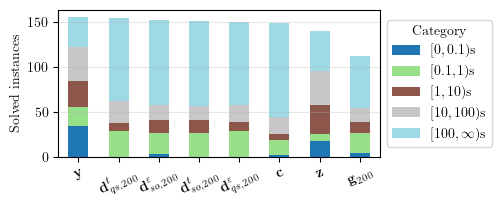

## Difficulty analysis on 200

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 34 (21.8%) | 22 (14.1%) | 28 (17.9%) | 38 (24.4%) | 34 (21.8%) | 156 / 177 (88.1%)
| $ \textbf{z} $ |  | 0 | 18 (12.9%) | 7 (5.0%) | 33 (23.6%) | 38 (27.1%) | 44 (31.4%) | 140 / 177 (79.1%)
| $ \textbf{c} $ |  | 0 | 2 (1.3%) | 17 (11.4%) | 6 (4.0%) | 19 (12.8%) | 105 (70.5%) | 149 / 177 (84.2%)
| $ \textbf{g}_{200} $ |  | 200 | 4 (3.6%) | 22 (19.6%) | 13 (11.6%) | 15 (13.4%) | 58 (51.8%) | 112 / 177 (63.3%)
| $ \textbf{d}_{so,200}^\varepsilon $ |  | 200 | 3 (2.0%) | 24 (15.7%) | 14 (9.2%) | 17 (11.1%) | 95 (62.1%) | 153 / 177 (86.4%)
| $ \textbf{d}_{so,200}^t $ | ✔ | 200 | 0 | 27 (17.9%) | 14 (9.3%) | 16 (10.6%) | 94 (62.3%) | 151 / 177 (85.3%)
| $ \textbf{d}_{qs,200}^\varepsilon $ |  | 200 | 0 | 29 (19.3%) | 10 (6.7%) | 19 (12.7%) | 92 (61.3%) | 150 / 177 (84.7%)
| $ \textbf{d}_{qs,200}^t $ | ✔ | 200 | 0 | 29 (18.7%) | 9 (5.8%) | 24 (15.5%) | 93 (60.0%) | 155 / 177 (87.6%)


In [19]:
md(difficulty_analysis(
    solvers_analysis=[
        others_results["yices"].apply_filter(lambda df: in_n(df, 200)),
        others_results["z3"].apply_filter(lambda df: in_n(df, 200)),
        others_results["cvc5"].apply_filter(lambda df: in_n(df, 200)),
        others_results["glpk_i200"],
        results["soplex_i200"],
        results["soplex_i200_strict"],
        results["qsoptex_i200"],
        results["qsoptex_i200_strict"],
    ],
   total_count= len(instances_200),
   group_name="200",
))

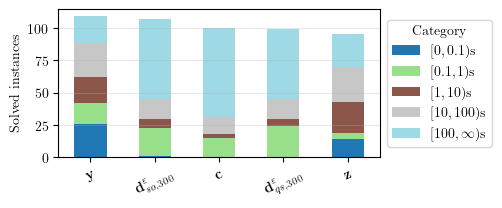

## Difficulty analysis on 300

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 26 (23.9%) | 16 (14.7%) | 20 (18.3%) | 26 (23.9%) | 21 (19.3%) | 109 / 125 (87.2%)
| $ \textbf{z} $ |  | 0 | 14 (14.7%) | 5 (5.3%) | 24 (25.3%) | 27 (28.4%) | 25 (26.3%) | 95 / 125 (76.0%)
| $ \textbf{c} $ |  | 0 | 0 | 15 (15.0%) | 3 (3.0%) | 13 (13.0%) | 69 (69.0%) | 100 / 125 (80.0%)
| $ \textbf{d}_{so,300}^\varepsilon $ |  | 300 | 1 (0.9%) | 22 (20.6%) | 7 (6.5%) | 15 (14.0%) | 62 (57.9%) | 107 / 125 (85.6%)
| $ \textbf{d}_{qs,300}^\varepsilon $ |  | 300 | 0 | 24 (24.2%) | 6 (6.1%) | 15 (15.2%) | 54 (54.5%) | 99 / 125 (79.2%)


In [20]:
md(difficulty_analysis(
    solvers_analysis=[
        others_results["yices"].apply_filter(lambda df: in_n(df, 300)),
        others_results["z3"].apply_filter(lambda df: in_n(df, 300)),
        others_results["cvc5"].apply_filter(lambda df: in_n(df, 300)),
        # others_results["glpk_i300"],
        results["soplex_i300"],
        # results["soplex_i300_strict"],
        results["qsoptex_i300"],
        # results["qsoptex_i300_strict"],
    ],
   total_count= len(instances_300),
   group_name="300",
))

In [21]:
def difficulty_analysis_by_group(group: pd.DataFrame, iterations: int, group_name: str = "QF_LRA"):
    if iterations == 100:
        instances_filter = instances_100
        return md(difficulty_analysis(
            solvers_analysis=[
                others_results["yices"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["z3"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["cvc5"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["glpk_i100"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["soplex_i100"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["soplex_i100_strict"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["qsoptex_i100"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["qsoptex_i100_strict"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
             ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=group_name
        ))
    elif iterations == 200:
        instances_filter = instances_200
        return md(difficulty_analysis(
            solvers_analysis=[
                others_results["yices"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["z3"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["cvc5"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["glpk_i200"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["soplex_i200"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["soplex_i200_strict"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["qsoptex_i200"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["qsoptex_i200_strict"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
             ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=group_name
        ))

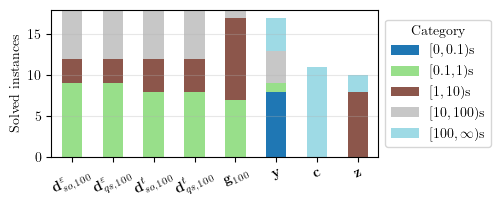

## Difficulty analysis on Lanteresse

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 8 (47.1%) | 1 (5.9%) | 0 | 4 (23.5%) | 4 (23.5%) | 17 / 18 (94.4%)
| $ \textbf{z} $ |  | 0 | 0 | 0 | 8 (80.0%) | 0 | 2 (20.0%) | 10 / 18 (55.6%)
| $ \textbf{c} $ |  | 0 | 0 | 0 | 0 | 0 | 11 (100.0%) | 11 / 18 (61.1%)
| $ \textbf{g}_{100} $ |  | 100 | 0 | 7 (38.9%) | 10 (55.6%) | 1 (5.6%) | 0 | 18 / 18 (100.0%)
| $ \textbf{d}_{so,100}^\varepsilon $ |  | 100 | 0 | 9 (50.0%) | 3 (16.7%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)
| $ \textbf{d}_{so,100}^t $ | ✔ | 100 | 0 | 8 (44.4%) | 4 (22.2%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)
| $ \textbf{d}_{qs,100}^\varepsilon $ |  | 100 | 0 | 9 (50.0%) | 3 (16.7%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)
| $ \textbf{d}_{qs,100}^t $ | ✔ | 100 | 0 | 8 (44.4%) | 4 (22.2%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)


In [22]:
difficulty_analysis_by_group(lanteresse, 100, "Lanteresse")

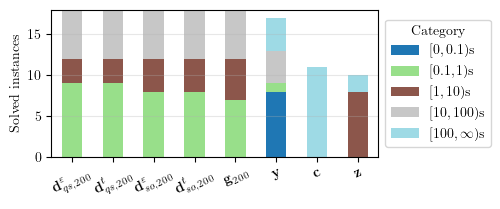

## Difficulty analysis on Lanteresse

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 8 (47.1%) | 1 (5.9%) | 0 | 4 (23.5%) | 4 (23.5%) | 17 / 18 (94.4%)
| $ \textbf{z} $ |  | 0 | 0 | 0 | 8 (80.0%) | 0 | 2 (20.0%) | 10 / 18 (55.6%)
| $ \textbf{c} $ |  | 0 | 0 | 0 | 0 | 0 | 11 (100.0%) | 11 / 18 (61.1%)
| $ \textbf{g}_{200} $ |  | 200 | 0 | 7 (38.9%) | 5 (27.8%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)
| $ \textbf{d}_{so,200}^\varepsilon $ |  | 200 | 0 | 8 (44.4%) | 4 (22.2%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)
| $ \textbf{d}_{so,200}^t $ | ✔ | 200 | 0 | 8 (44.4%) | 4 (22.2%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)
| $ \textbf{d}_{qs,200}^\varepsilon $ |  | 200 | 0 | 9 (50.0%) | 3 (16.7%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)
| $ \textbf{d}_{qs,200}^t $ | ✔ | 200 | 0 | 9 (50.0%) | 3 (16.7%) | 6 (33.3%) | 0 | 18 / 18 (100.0%)


In [23]:
difficulty_analysis_by_group(lanteresse, 200, "Lanteresse")

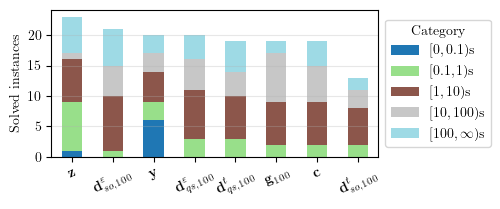

## Difficulty analysis on MPLIB

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 6 (30.0%) | 3 (15.0%) | 5 (25.0%) | 3 (15.0%) | 3 (15.0%) | 20 / 27 (74.1%)
| $ \textbf{z} $ |  | 0 | 1 (4.3%) | 8 (34.8%) | 7 (30.4%) | 1 (4.3%) | 6 (26.1%) | 23 / 27 (85.2%)
| $ \textbf{c} $ |  | 0 | 0 | 2 (10.5%) | 7 (36.8%) | 6 (31.6%) | 4 (21.1%) | 19 / 27 (70.4%)
| $ \textbf{g}_{100} $ |  | 100 | 0 | 2 (10.5%) | 7 (36.8%) | 8 (42.1%) | 2 (10.5%) | 19 / 27 (70.4%)
| $ \textbf{d}_{so,100}^\varepsilon $ |  | 100 | 0 | 1 (4.8%) | 9 (42.9%) | 5 (23.8%) | 6 (28.6%) | 21 / 27 (77.8%)
| $ \textbf{d}_{so,100}^t $ | ✔ | 100 | 0 | 2 (15.4%) | 6 (46.2%) | 3 (23.1%) | 2 (15.4%) | 13 / 27 (48.1%)
| $ \textbf{d}_{qs,100}^\varepsilon $ |  | 100 | 0 | 3 (15.0%) | 8 (40.0%) | 5 (25.0%) | 4 (20.0%) | 20 / 27 (74.1%)
| $ \textbf{d}_{qs,100}^t $ | ✔ | 100 | 0 | 3 (15.8%) | 7 (36.8%) | 4 (21.1%) | 5 (26.3%) | 19 / 27 (70.4%)


In [24]:
difficulty_analysis_by_group(mplib, 100, "MPLIB")


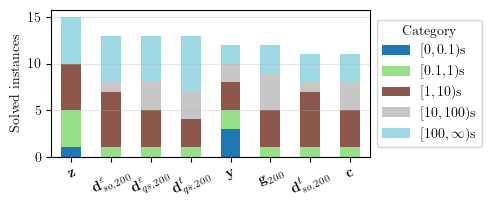

## Difficulty analysis on MPLIB

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 3 (25.0%) | 2 (16.7%) | 3 (25.0%) | 2 (16.7%) | 2 (16.7%) | 12 / 19 (63.2%)
| $ \textbf{z} $ |  | 0 | 1 (6.7%) | 4 (26.7%) | 5 (33.3%) | 0 | 5 (33.3%) | 15 / 19 (78.9%)
| $ \textbf{c} $ |  | 0 | 0 | 1 (9.1%) | 4 (36.4%) | 3 (27.3%) | 3 (27.3%) | 11 / 19 (57.9%)
| $ \textbf{g}_{200} $ |  | 200 | 0 | 1 (8.3%) | 4 (33.3%) | 4 (33.3%) | 3 (25.0%) | 12 / 19 (63.2%)
| $ \textbf{d}_{so,200}^\varepsilon $ |  | 200 | 0 | 1 (7.7%) | 6 (46.2%) | 1 (7.7%) | 5 (38.5%) | 13 / 19 (68.4%)
| $ \textbf{d}_{so,200}^t $ | ✔ | 200 | 0 | 1 (9.1%) | 6 (54.5%) | 1 (9.1%) | 3 (27.3%) | 11 / 19 (57.9%)
| $ \textbf{d}_{qs,200}^\varepsilon $ |  | 200 | 0 | 1 (7.7%) | 4 (30.8%) | 3 (23.1%) | 5 (38.5%) | 13 / 19 (68.4%)
| $ \textbf{d}_{qs,200}^t $ | ✔ | 200 | 0 | 1 (7.7%) | 3 (23.1%) | 3 (23.1%) | 6 (46.2%) | 13 / 19 (68.4%)


In [25]:
difficulty_analysis_by_group(mplib, 200, "MPLIB")

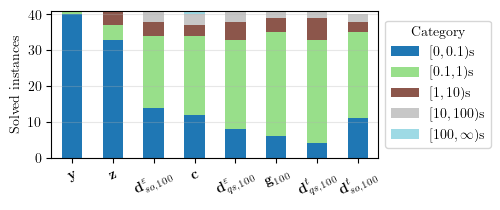

## Difficulty analysis on DTP Scheduling

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 40 (97.6%) | 1 (2.4%) | 0 | 0 | 0 | 41 / 41 (100.0%)
| $ \textbf{z} $ |  | 0 | 33 (80.5%) | 4 (9.8%) | 4 (9.8%) | 0 | 0 | 41 / 41 (100.0%)
| $ \textbf{c} $ |  | 0 | 12 (29.3%) | 22 (53.7%) | 3 (7.3%) | 3 (7.3%) | 1 (2.4%) | 41 / 41 (100.0%)
| $ \textbf{g}_{100} $ |  | 100 | 6 (14.6%) | 29 (70.7%) | 4 (9.8%) | 2 (4.9%) | 0 | 41 / 41 (100.0%)
| $ \textbf{d}_{so,100}^\varepsilon $ |  | 100 | 14 (34.1%) | 20 (48.8%) | 4 (9.8%) | 3 (7.3%) | 0 | 41 / 41 (100.0%)
| $ \textbf{d}_{so,100}^t $ | ✔ | 100 | 11 (27.5%) | 24 (60.0%) | 3 (7.5%) | 2 (5.0%) | 0 | 40 / 41 (97.6%)
| $ \textbf{d}_{qs,100}^\varepsilon $ |  | 100 | 8 (19.5%) | 25 (61.0%) | 5 (12.2%) | 3 (7.3%) | 0 | 41 / 41 (100.0%)
| $ \textbf{d}_{qs,100}^t $ | ✔ | 100 | 4 (9.8%) | 29 (70.7%) | 6 (14.6%) | 2 (4.9%) | 0 | 41 / 41 (100.0%)


In [26]:
difficulty_analysis_by_group(dtp_scheduling, 100, "DTP Scheduling")

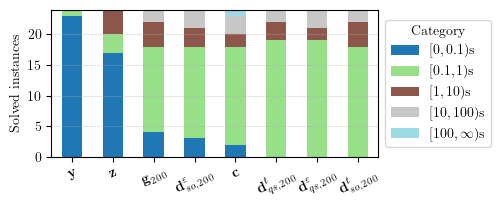

## Difficulty analysis on DTP Scheduling

All problems are divided into buckets depending on the time taken by the solver to solve them.

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 23 (95.8%) | 1 (4.2%) | 0 | 0 | 0 | 24 / 24 (100.0%)
| $ \textbf{z} $ |  | 0 | 17 (70.8%) | 3 (12.5%) | 4 (16.7%) | 0 | 0 | 24 / 24 (100.0%)
| $ \textbf{c} $ |  | 0 | 2 (8.3%) | 16 (66.7%) | 2 (8.3%) | 3 (12.5%) | 1 (4.2%) | 24 / 24 (100.0%)
| $ \textbf{g}_{200} $ |  | 200 | 4 (16.7%) | 14 (58.3%) | 4 (16.7%) | 2 (8.3%) | 0 | 24 / 24 (100.0%)
| $ \textbf{d}_{so,200}^\varepsilon $ |  | 200 | 3 (12.5%) | 15 (62.5%) | 3 (12.5%) | 3 (12.5%) | 0 | 24 / 24 (100.0%)
| $ \textbf{d}_{so,200}^t $ | ✔ | 200 | 0 | 18 (75.0%) | 4 (16.7%) | 2 (8.3%) | 0 | 24 / 24 (100.0%)
| $ \textbf{d}_{qs,200}^\varepsilon $ |  | 200 | 0 | 19 (79.2%) | 2 (8.3%) | 3 (12.5%) | 0 | 24 / 24 (100.0%)
| $ \textbf{d}_{qs,200}^t $ | ✔ | 200 | 0 | 19 (79.2%) | 3 (12.5%) | 2 (8.3%) | 0 | 24 / 24 (100.0%)


In [27]:
difficulty_analysis_by_group(dtp_scheduling, 200, "DTP Scheduling")

In [28]:
def to_new_solver_id(solver_result: SolverResult):
    return f"{solver_result.solver_id}{solver_result.iterations}{'S' if '^t' in solver_result.solver_name.lower() else ''}{'D' if r'\delta' in solver_result.solver_name.lower() else ''}"

cvc5_variants_results = [
    SolverResult(
        dataframe=solver_result.dataframe.reset_index()[
            ["file", f"time{solver_result.solver_id}", f"result{solver_result.solver_id}", *(["options::pivots"] if "options::pivots" in solver_result.dataframe.columns else [])]
        ]
        .rename(
            columns={
                f"time{solver_result.solver_id}": f"time{to_new_solver_id(solver_result)}",
                f"result{solver_result.solver_id}": f"result{to_new_solver_id(solver_result)}",
            }
        )
        .set_index("file"),
        solver_name=solver_result.solver_name,
        solver_id=to_new_solver_id(solver_result),
        iterations=solver_result.iterations,
    )
    for solver_result in (results | others_results).values()
    if solver_result.solver_id in ["C", "S", "Q", "G"]
]

other_profile_results = [
    SolverResult(
        dataframe=solver_result.dataframe.reset_index()[
            ["file", f"time{solver_result.solver_id}", f"result{solver_result.solver_id}"]
        ]
        .rename(
            columns={
                f"time{solver_result.solver_id}": f"time{to_new_solver_id(solver_result)}",
                f"result{solver_result.solver_id}": f"result{to_new_solver_id(solver_result)}",
            }
        )
        .set_index("file"),
        solver_name=solver_result.solver_name,
        solver_id=to_new_solver_id(solver_result),
        iterations=solver_result.iterations,
    )
    for solver_result in others_results.values()
    if solver_result.solver_id in ["Y", "Z"]
]

# Get the set of instances where any of the SoPlex variants makes external simplex calls, and filter all profiles to only those instances
external_cvc5_variants_results: dict[int, list[SolverResult]] = {}
external_profile_results: dict[int, list[SolverResult]] = {}
for iteration in ITERATIONS:
        external_cvc5_variants_results[iteration] = [
            result.replace_df(in_n(result.dataframe.drop(columns=["options::pivots"], errors="ignore"), iteration))
            for result in cvc5_variants_results
            if "options::pivots" not in result.dataframe.columns or result.dataframe["options::pivots"].iloc[0] == iteration
        ]
        external_profile_results[iteration] = external_cvc5_variants_results[iteration] + [
            result.replace_df(in_n(result.dataframe, iteration)) for result in other_profile_results
        ]

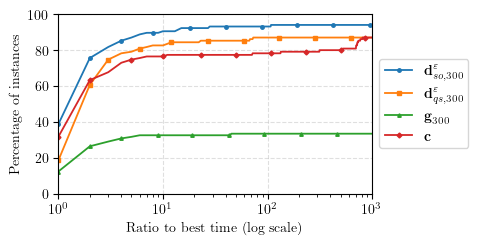

In [29]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants_results[300],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    num_points=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_300_cvc5.pgf", dpi=300)

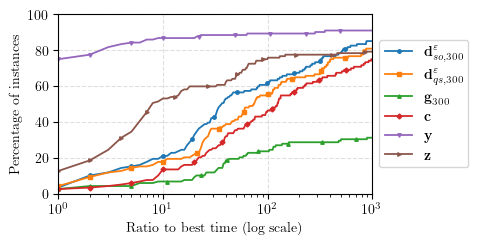

In [30]:
ax, fig = plot_performance_profiles(
    *external_profile_results[300],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    num_points=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_200_all.pgf", dpi=300)

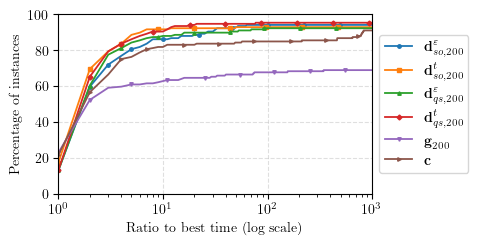

In [31]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants_results[200],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_200_cvc5.pgf", dpi=300)

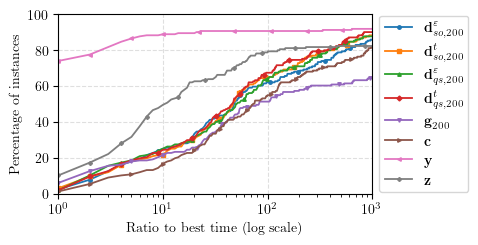

In [32]:
ax, fig = plot_performance_profiles(
    *external_profile_results[200],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_200_all.pgf", dpi=300)

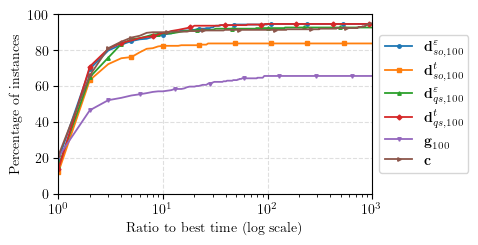

In [33]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants_results[100],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_100_cvc5.pgf", dpi=300)

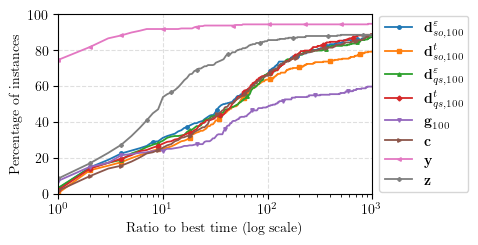

In [34]:
ax, fig = plot_performance_profiles(
    *external_profile_results[100],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_100_all.pgf", dpi=300)

In [35]:
column_map = {
    "timeY-1": r"$\textbf{y}$",
    "timeZ-1": r"$\textbf{z}$",
    "timeC-1": r"$\textbf{c}$",
    "timeG100": r"$\textbf{g}_{100}$",
    "timeG200": r"$\textbf{g}_{200}$",
    "timeG300": r"$\textbf{g}_{300}$",
    "timeS100": r"$\textbf{d}_{so,100}^\varepsilon$",
    "timeS100S": r"$\textbf{d}_{so,100}^t$",
    "timeS200": r"$\textbf{d}_{so,200}^\varepsilon$",
    "timeS200S": r"$\textbf{d}_{so,200}^t$",
    "timeS300": r"$\textbf{d}_{so,300}^\varepsilon$",
    "timeS300S": r"$\textbf{d}_{so,300}^t$",
    "timeQ100": r"$\textbf{d}_{qs,100}^\varepsilon$",
    "timeQ100S": r"$\textbf{d}_{qs,100S}^t$",
    "timeQ200": r"$\textbf{d}_{qs,200}^\varepsilon$",
    "timeQ200S": r"$\textbf{d}_{qs,200}^t$",
    "timeQ300": r"$\textbf{d}_{qs,300}^\varepsilon$",
    "timeQ300S": r"$\textbf{d}_{qs,300}^t$",
}

In [36]:
for iteration in ITERATIONS:
    df_all = reduce(
        lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how="outer"), (in_n(result.dataframe, iteration) for result in external_profile_results[iteration])
    )
    df_all_column_map = {col: name for col, name in column_map.items() if col in df_all.columns}
    df_all["problem_index"] = df_all.index
    df_all["problem_index"] = df_all["problem_index"].apply(lambda x: instances_dict[100].index.get_loc(x))
    df_all["Problem"] = df_all.index
    df_all["Problem"] = df_all["Problem"].apply(lambda x: f"({instances_dict[100].index.get_loc(x)})")
    df_all.sort_values("problem_index")[["Problem"] + list(df_all_column_map.keys())].rename(columns=df_all_column_map).to_latex(
        f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/all_times_{iteration}.tex",
        label=f"tab:all-times-{iteration}",
        caption=f"Running times for all solvers on instances belonging to the set $n={iteration}$.",
        position="h",
        float_format="%.1f",
        longtable=True,
        index=False,
        na_rep="-",
    )
instances_table = instances_dict[100].copy()
instances_table["File"] = instances_table.index
instances_table["Problem"] = instances_table["File"].apply(lambda x: f"({instances_dict[100].index.get_loc(x)})")
instances_table.reindex(columns=["Problem", "File"]).to_latex(
    "/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/all_instances.tex",
    label="tab:benchmark-map",
    caption="Mapping between numeric identifier and benchmark files.",
    longtable=True,
    index=False,
)

In [37]:
INTERESTING_COLS = [
    "global::totalTime",
    "theory::arith::z::arith::relax::calls",
    "theory::arith::z::approx::lp::setup::timer",
    "theory::arith::z::approx::lp::timer",
    "theory::arith::z::arith::relax::feasible::failures",
    "theory::arith::z::arith::relax::infeasible::failures",
    "theory::arith::z::approx::externalAdjustmentPivots",
    # "theory::arith::z::approx::precision",
    # "theory::arith::z::approx::refinements",
    # "theory::arith::attempt::extendedSearch",
]

# theory::arith::z::approx::precision	theory::arith::z::approx::refinements	theory::arith::attempt::extendedSearch

In [38]:
df = results["soplex_i100_strict"].dataframe
df[df["theory::arith::z::arith::relax::infeasible::failures"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
ecoliMILPglycerolYices3-50000.smt2,20856,39,570,1767,0,1,123


In [39]:
df[df["theory::arith::z::arith::relax::feasible::failures"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
vpm2-10.smt2,23028,20,64,80,4,0,417
danoint-266.smt2,163659,533,5385,19033,7,0,842
_standard_strcmp_ground.i_4_2_2.bpl_11.smt2,252680,10,279,227,1,0,101
_simple4.i_3_4_2.bpl_11.smt2,529499,134,427,2173,1,0,80
danoint-166.smt2,562820,2079,20634,95633,8,0,964
_const1.i_3_6_2.bpl_11.smt2,1556729,61,214,333,1,0,54
yPositive-SIscaled100.bpl_Iteration1_Loop_6-phaseTemplate.smt2,1574032,86,50482,42985,1,0,120
constraint-223827.smt2,3804733,343,4035,3707,4,0,480
hongyi1.t2.c_Iteration1_Loop_4-pieceTemplate.smt2,10284442,177,175909,121768,5,0,600


In [40]:
df[(df["theory::arith::z::approx::externalAdjustmentPivots"] > 0) & (df["theory::arith::z::arith::relax::feasible::failures"] == 0) & (df["theory::arith::z::arith::relax::infeasible::failures"] == 0)][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
constraints-tms-2-3-light-20.smt2,120,1,1,1,0,0,1
constraints-tms-2-3-light-60.smt2,203,2,8,8,0,0,1
constraints-tms-2-3-light-70.smt2,238,2,10,8,0,0,2
constraints-tms-2-3-light-80.smt2,284,2,12,9,0,0,2
constraints-tms-2-3-light-90.smt2,333,2,12,11,0,0,3
vpm2-5.smt2,1343,6,20,28,0,0,3
vpm2-30.smt2,3173,7,24,37,0,0,2
clocksynchro_6clocks.main_invar.induct.smt2,9992,5,20,52,0,0,8
clocksynchro_9clocks.worst_case_skew.induct.smt2,13907,1,2,8,0,0,1


In [41]:
df[df["theory::arith::z::arith::relax::other"] > 0][INTERESTING_COLS].sort_values("global::totalTime")


,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,


In [42]:
# compare_df = pd.merge(results["qsoptex_i100_delta1e-08"].dataframe, others_results["yices"].dataframe, left_index=True, right_index=True)
# compare_df[compare_df["resultQ"] != compare_df["resultY"]]
# compare_df